# AG-HYPOPT · Trial 03

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Registry holds two trials: trial_01 (obj 0.1907, best) and trial_02 (obj 0.2075). Both used random warm-up configs and both show the same picture: mu_fit stuck well below mu_true (a ~half-truth attractor, wider for trial_02), and gamma_fit good only at high transmission (low-transmission collapse). Proposer still in the uniform warm-up phase (2/5 completed), so candidates remain independent uniform draws with no exploitable ranking information. Context only.


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_03'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 20    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = uniform  (2/5 trials)
ID |     ei | params
 1 |      - | {"gamma_anneal": 0.06423687535771827, "lr_gamma": 0.3894484052768798, "lr_mu": 25.031861630159923, "sigma_ref": 16.643240721287356}
 2 |      - | {"gamma_anneal": 0.07059648168029939, "lr_gamma": 0.5465015521891791, "lr_mu": 16.976282453520852, "sigma_ref": 8.19477829274157}
 3 |      - | {"gamma_anneal": 0.5509328635569108, "lr_gamma": 0.29093761593712275, "lr_mu": 14.78070476239155, "sigma_ref": 15.334803652427274}
 4 |      - | {"gamma_anneal": 0.3229710153106333, "lr_gamma": 0.6694388571505125, "lr_mu": 23.445944682304006, "sigma_ref": 24.125345096721972}
 5 |      - | {"gamma_anneal": 0.2131508728115936, "lr_gamma": 0.71883776566386, "lr_mu": 22.405399916753886, "sigma_ref": 10.854414980249743}
 6 |      - | {"gamma_anneal": 0.001117562631627128, "lr_gamma": 0.9787682198131302, "lr_mu": 12.460030575421891, "sigma_ref": 11.279720040686737}
 7 |      - | {"gamma_anneal": 0.6687833028338679, "lr_gamma": 0.66813035191272

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

Two completed trials (trial_01 0.1907, trial_02 0.2075) and the proposer is still in the uniform warm-up phase (2/5), so there is no exploiter/interpreter model and the candidates carry no ranking signal -- they are indistinguishable a priori. With nothing to discriminate between them, I take the first enumerated proposal. I choose candidate 1.


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 1               # first candidate (uniform phase, no ranking signal)


chosen: {'gamma_anneal': 0.06423687535771827, 'lr_gamma': 0.3894484052768798, 'lr_mu': 25.031861630159923, 'sigma_ref': 16.643240721287356}
Running  1nW Trans05 ... 

μ 9.39 -> 4.75 | γ 8.5 -> 1.33 | NLL 1.29


Running  1nW Trans20 ... 

μ 17.32 -> 8.62 | γ 8.5 -> 4.08 | NLL 2.81


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 46.35 | γ 14.1 -> 12.51 | NLL 3.38


Running 3nW Trans100 ... 

μ 175.71 -> 78.51 | γ 14.1 -> 12.97 | NLL 3.02



Total: 2.4 min


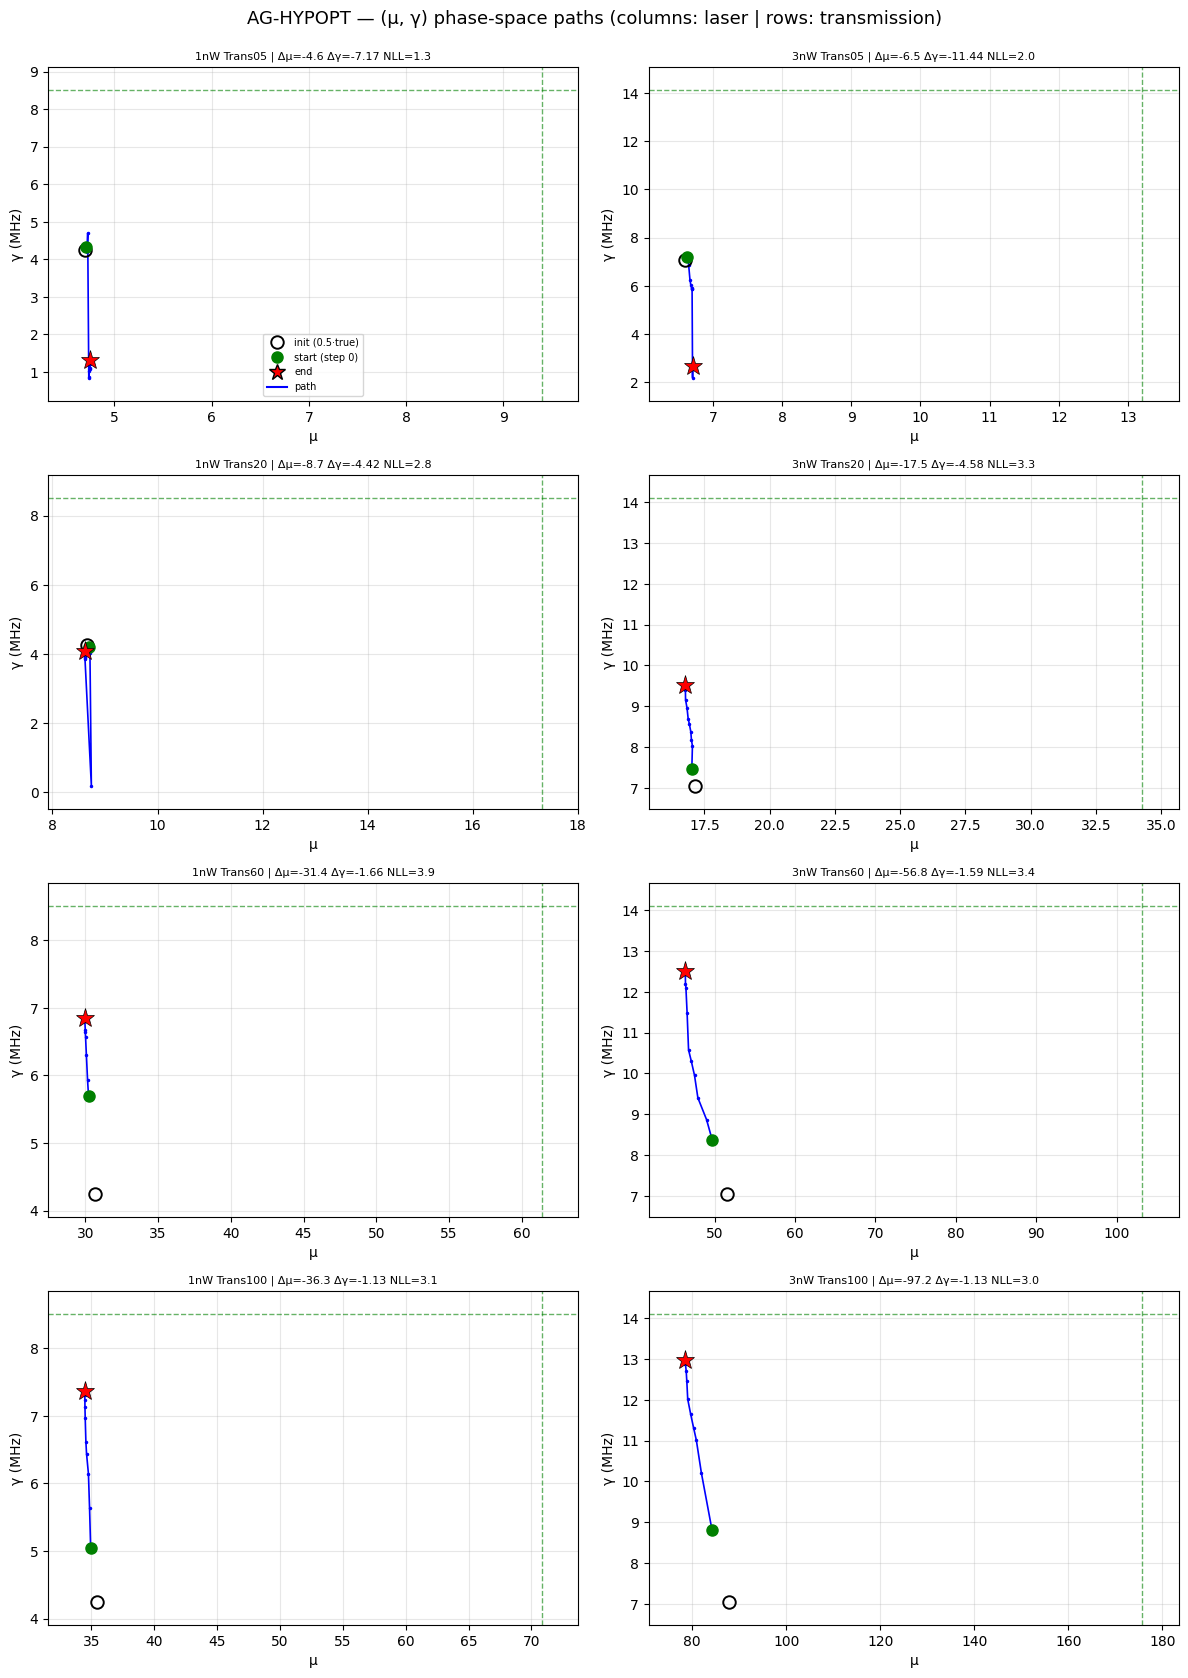

trial finished in 2.4 min
objective = 0.2472 ± 0.0509
exp           μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05     9.39    4.75   -49.4 |     8.50    1.33   -84.4
1nW Trans20    17.32    8.62   -50.2 |     8.50    4.08   -52.0
1nW Trans60    61.37   29.96   -51.2 |     8.50    6.84   -19.5
1nW Trans100   70.82   34.47   -51.3 |     8.50    7.37   -13.3
3nW Trans05    13.20    6.71   -49.2 |    14.10    2.66   -81.1
3nW Trans20    34.28   16.77   -51.1 |    14.10    9.52   -32.5
3nW Trans60   103.20   46.35   -55.1 |    14.10   12.51   -11.3
3nW Trans100  175.71   78.51   -55.3 |    14.10   12.97    -8.0

μ: RMSE 43.923 (rel 51.6%, bias -32.393) | γ: RMSE 5.369 (rel 47.7%, bias -4.140)


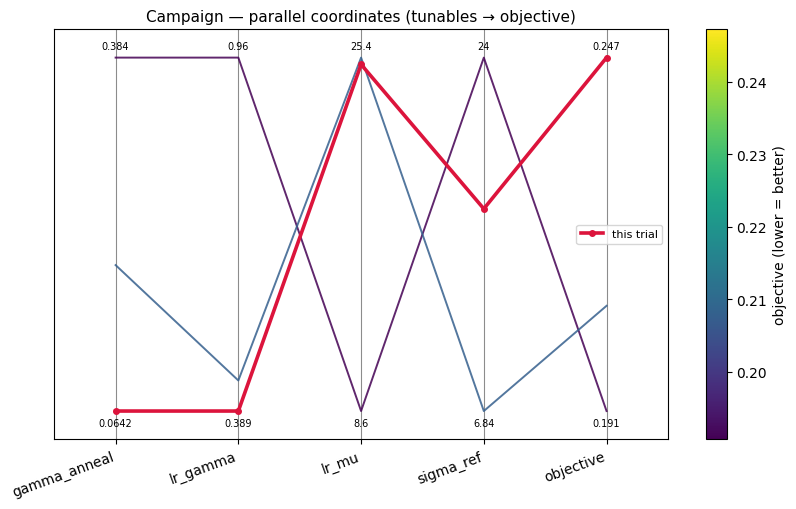

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 03, third trial; proposer still in the uniform warm-up phase (2/5), so config is an uninformative random draw: sigma_ref 16.64, lr_mu 25.03, lr_gamma 0.389, gamma_anneal 0.064. Result: objective 0.2472 +/- 0.0509, the worst of the three trials so far (trial_01 0.1907, trial_02 0.2075), runtime 2.4 min. mu_fit is again near half of mu_true and fairly uniform (Delta-mu% -49.2 to -55.3), mu RMSE 43.92 (relative 51.6%, bias -32.4) -- back to the clean attractor of trial_01. gamma_fit is good at high transmission (3 nW Trans60/100: -11.3%/-8.0%; 1 nW Trans100: -13.3%) but collapses hard at Trans05 with this config (1 nW -84.4%, 3 nW -81.1%), pushing gamma RMSE to 5.37 (relative 47.7%, bias -4.1), clearly worse than both prior trials. The near-zero gamma_anneal (0.064) coincides with the strongest low-transmission gamma collapse seen so far.

**Summary:** Trial 03 (sigma_ref 16.64, lr_mu 25.03, lr_gamma 0.389, gamma_anneal 0.064) -> objective 0.2472 +/- 0.0509, worst so far; mu attractor persists near half-truth, gamma collapses hard (to ~-82%) at Trans05.
**Key insight:** With essentially no gamma anneal (0.064), the low-transmission gamma estimate degenerated to ~15-20% of truth on both laser powers, the single largest loss contribution in the campaign so far.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
No new structural notes; the real-data attractor note from trial_01 still stands.


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'Trial 03 (sigma_ref 16.64, lr_mu 25.03, lr_gamma 0.389, gamma_anneal 0.064): objective 0.2472 +/- 0.0509, worst so far; mu attractor near half-truth, gamma collapses to ~-82% at Trans05'
KEY_INSIGHT = 'Near-zero gamma anneal (0.064) coincides with a hard low-transmission gamma collapse (~15-20% of truth on both powers), the largest single loss contributor so far.'


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_03 | current best: trial_01


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_04.ipynb. Open it and follow its cells from the top.
